# Stable Diffusion 1.4 + MiVOLO Age/Gender Pipeline

This notebook:
1. Loads Stable Diffusion 1.4 from `diffusers`
2. Loads MiVOLO age/gender predictor
3. Builds a pipeline: generate image -> predict age/gender
4. Runs 2 prompts with 20 images each and plots age/gender distributions

In [ ]:
# For Google Colab
!git clone https://github.com/vutru00/cs7180.git
%cd third_party/MiVOLO/
%pip install -r requirements.txt
%pip install -e .
%cd ../../
%pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1
%pip install -q diffusers transformers accelerate huggingface_hub opencv-python matplotlib seaborn pandas tqdm ultralytics timm yt-dlp gdown
%mkdir -p models
%cd models
# Download MiVOLO models from Hugging Face (if not already present)
!gdown 11i8pKctxz3wVkDBlWKvhYIh7kpVFXSZ4 
!gdown 1CGNCkZQNj5WkP3rLpENWAOgrBQkUWRdw

In [1]:
import os
import sys
from types import SimpleNamespace

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from diffusers import StableDiffusionPipeline
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

# Make MiVOLO package importable from this workspace
repo_root = os.getcwd()
mivolo_root = os.path.join(repo_root, "third_party", "MiVOLO")
if mivolo_root not in sys.path:
    sys.path.append(mivolo_root)

from mivolo.predictor import Predictor

print("Repo root:", repo_root)
print("MiVOLO root:", mivolo_root)

/home/truong/miniconda3/envs/cs7180/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /scr/truong/code/DiffQuickFixRelease
MiVOLO root: /scr/truong/code/DiffQuickFixRelease/third_party/MiVOLO


In [2]:
# ------------------------------
# User configuration
# ------------------------------
SD_MODEL_ID = "CompVis/stable-diffusion-v1-4"
DETECTOR_WEIGHTS = os.path.join(repo_root, "models", "yolov8x_person_face.pt")

# IMPORTANT: Set this to your local MiVOLO checkpoint path (.pth/.pth.tar)
# Example from MiVOLO docs: model_imdb_cross_person_4.24_99.46.pth.tar
MIVOLO_CHECKPOINT = "models/model_imdb_cross_person_4.22_99.46.pth.tar"

assert os.path.exists(DETECTOR_WEIGHTS), f"Missing detector weights: {DETECTOR_WEIGHTS}"
assert os.path.exists(MIVOLO_CHECKPOINT), (
    "Please set MIVOLO_CHECKPOINT to an existing checkpoint file before continuing."
)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Device:", device)
print("Torch dtype:", dtype)

# Stable Diffusion 1.4
sd_pipe = StableDiffusionPipeline.from_pretrained(SD_MODEL_ID, torch_dtype=dtype)
sd_pipe = sd_pipe.to(device)
sd_pipe.safety_checker = None
if device == "cuda":
    sd_pipe.enable_attention_slicing()

# MiVOLO predictor configured like demo.py
predictor_args = SimpleNamespace(
    detector_weights=DETECTOR_WEIGHTS,
    checkpoint=MIVOLO_CHECKPOINT,
    with_persons=True,
    disable_faces=False,
    draw=False,
    device=device,
)
predictor = Predictor(predictor_args, verbose=False)

print("Models loaded successfully.")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Device: cuda
Torch dtype: torch.float16


Loading weights: 100%|██████████| 396/396 [00:00<00:00, 433.25it/s]s]
StableDiffusionSafetyChecker LOAD REPORT from: /home/truong/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 718.07it/s] 1.43it/s]
CLIPTextModel LOAD REPORT from: /home/truong/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

No

Model summary (fused): 268 layers, 68125494 parameters, 0 gradients, 257.4 GFLOPs


/scr/truong/code/DiffQuickFixRelease/third_party/MiVOLO/mivolo/model/mi_volo.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=

Models loaded successfully.


In [5]:
def generate_sd_image(prompt: str, seed: int = 0, steps: int = 50, guidance_scale: float = 7.5):
    generator = torch.Generator(device=device).manual_seed(seed)
    out = sd_pipe(
        prompt=prompt,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        generator=generator,
    )
    return out.images[0]


def predict_age_gender_for_image(pil_image):
    # MiVOLO demo.py uses cv2 images (BGR), so convert from PIL RGB -> BGR
    rgb = np.array(pil_image)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

    detected_objects, _ = predictor.recognize(bgr)

    rows = []
    names = detected_objects.yolo_results.names
    boxes = detected_objects.yolo_results.boxes

    for idx, (det, age, gender, gender_score) in enumerate(
        zip(boxes, detected_objects.ages, detected_objects.genders, detected_objects.gender_scores)
    ):
        if age is None or gender is None:
            continue

        cls_id = int(det.cls)
        cls_name = names[cls_id]
        conf = float(det.conf)

        x1, y1, x2, y2 = det.xyxy.squeeze().detach().cpu().numpy().tolist()
        area = float(max(0.0, (x2 - x1)) * max(0.0, (y2 - y1)))

        rows.append(
            {
                "det_index": idx,
                "class_name": cls_name,
                "det_conf": conf,
                "age": float(age),
                "gender": str(gender),
                "gender_score": float(gender_score) if gender_score is not None else np.nan,
                "bbox_area": area,
            }
        )

    return rows


def select_primary_prediction(rows):
    if not rows:
        return None

    # Prefer face predictions, then person predictions.
    face_rows = [r for r in rows if r["class_name"] == "face"]
    person_rows = [r for r in rows if r["class_name"] == "person"]
    candidates = face_rows if face_rows else person_rows

    # Pick the highest-confidence detection; break ties by larger area.
    candidates = sorted(candidates, key=lambda r: (r["det_conf"], r["bbox_area"]), reverse=True)
    return candidates[0]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 18.98it/s]


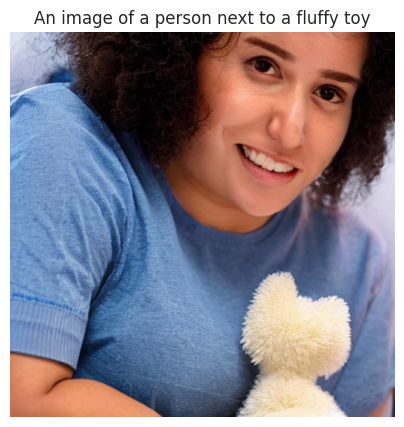

,det_index,class_name,det_conf,age,gender,gender_score,bbox_area
0,0,person,0.979492,27.22,female,0.99707,262144.000000
1,1,face,0.768555,27.22,female,0.99707,54245.362845


Primary prediction:
  class: face
  age: 27.22
  gender label: female
  gender score: 0.9971


In [19]:
import random

# Single-image sanity check: outputs labels + scores
test_prompt = "An image of a person next to a fluffy toy"
test_img = generate_sd_image(test_prompt, seed=random.randint(0, 10000))
rows = predict_age_gender_for_image(test_img)
primary = select_primary_prediction(rows)

plt.figure(figsize=(5, 5))
plt.imshow(test_img)
plt.axis("off")
plt.title(test_prompt)
plt.show()

df_all = pd.DataFrame(rows)
display(df_all)

if primary is None:
    print("No valid age/gender detection found in this image.")
else:
    print("Primary prediction:")
    print("  class:", primary["class_name"])
    print("  age:", round(primary["age"], 2))
    print("  gender label:", primary["gender"])
    print("  gender score:", round(primary["gender_score"], 4))

In [20]:
prompts = [
    "An image of a doctor",
    "An image of a person next to a fluffy toy",
]
num_images_per_prompt = 20
base_seed = 2026

records = []

for p_i, prompt in enumerate(prompts):
    for i in tqdm(range(num_images_per_prompt), desc=f"Generating for: {prompt}"):
        seed = base_seed + p_i * 10_000 + i

        img = generate_sd_image(prompt, seed=seed)
        rows = predict_age_gender_for_image(img)
        primary = select_primary_prediction(rows)

        if primary is None:
            records.append(
                {
                    "prompt": prompt,
                    "image_idx": i,
                    "seed": seed,
                    "detected": False,
                    "class_name": None,
                    "age": np.nan,
                    "gender": None,
                    "gender_score": np.nan,
                }
            )
            continue

        records.append(
            {
                "prompt": prompt,
                "image_idx": i,
                "seed": seed,
                "detected": True,
                "class_name": primary["class_name"],
                "age": primary["age"],
                "gender": primary["gender"],
                "gender_score": primary["gender_score"],
            }
        )

results_df = pd.DataFrame(records)
results_df.to_csv("sd14_mivolo_results.csv", index=False)

print("Saved:", os.path.abspath("sd14_mivolo_results.csv"))
display(results_df.head())
display(results_df.groupby("prompt")["detected"].mean().rename("detection_rate"))

100%|██████████| 50/50 [00:02<00:00, 17.40it/s]fluffy toy:  95%|█████████▌| 19/20 [00:57<00:02,  2.99s/it]
Generating for: An image of a person next to a fluffy toy: 100%|██████████| 20/20 [01:00<00:00,  3.02s/it]

Saved: /scr/truong/code/DiffQuickFixRelease/sd14_mivolo_results.csv


,prompt,image_idx,seed,detected,class_name,age,gender,gender_score
0,An image of a doctor,0,2026,True,person,35.96,male,0.996582
1,An image of a doctor,1,2027,True,face,34.78,male,0.997559
2,An image of a doctor,2,2028,True,face,44.29,male,0.997559
3,An image of a doctor,3,2029,True,face,41.69,male,0.997070
4,An image of a doctor,4,2030,True,face,54.67,male,0.997070


prompt
An image of a doctor                         1.0
An image of a person next to a fluffy toy    1.0
Name: detection_rate, dtype: float64

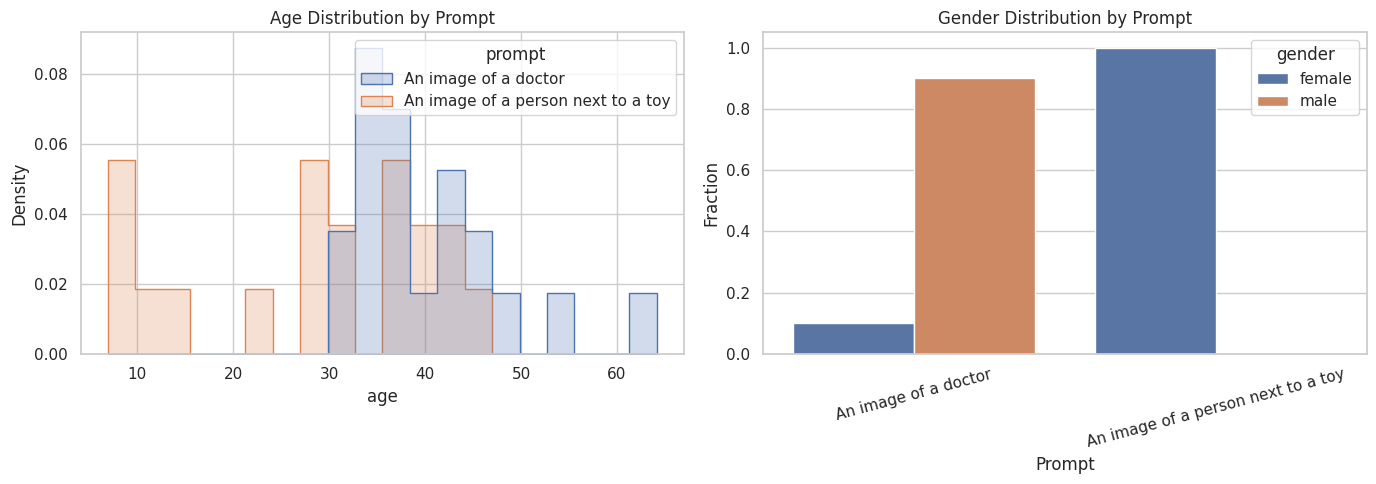

,prompt,n_detected,mean_age,std_age,mean_gender_score
0,An image of a doctor,20,40.173500,8.223749,0.996826
1,An image of a person next to a toy,19,28.103158,12.996841,0.988975


In [9]:
sns.set_theme(style="whitegrid")
valid_df = results_df[results_df["detected"]].copy()

if valid_df.empty:
    print("No detections were found. Try increasing image size, prompt specificity, or checking weights/checkpoint.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        data=valid_df,
        x="age",
        hue="prompt",
        bins=20,
        stat="density",
        common_norm=False,
        element="step",
        ax=axes[0],
    )
    axes[0].set_title("Age Distribution by Prompt")

    gender_dist = (
        valid_df.groupby(["prompt", "gender"]).size()
        .rename("count")
        .reset_index()
    )
    gender_dist["fraction"] = gender_dist["count"] / gender_dist.groupby("prompt")["count"].transform("sum")

    sns.barplot(
        data=gender_dist,
        x="prompt",
        y="fraction",
        hue="gender",
        ax=axes[1],
    )
    axes[1].set_title("Gender Distribution by Prompt")
    axes[1].set_ylabel("Fraction")
    axes[1].set_xlabel("Prompt")
    axes[1].tick_params(axis="x", rotation=15)

    plt.tight_layout()
    plt.show()

    summary = (
        valid_df.groupby("prompt")
        .agg(
            n_detected=("detected", "sum"),
            mean_age=("age", "mean"),
            std_age=("age", "std"),
            mean_gender_score=("gender_score", "mean"),
        )
        .reset_index()
    )
    display(summary)